# STEP 1 — Import Libraries

In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
# import transformers
# print(transformers.__version__)
# print(torch.__version__)
# print(torch.version.cuda)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

# STEP 2 — Load Dataset (final_combined.csv)

In [24]:
df = pd.read_csv("../../datasets/final/final_combined.csv")

# Keep only subject + label
df_subject = df[["subject", "label"]].dropna()
df_subject["subject"] = df_subject["subject"].astype(str)

print(df_subject.head())
print("Total samples:", len(df_subject))

                                        subject  label
0  new Catholic mailing list now up and running      0
1                                       re[12]:      1
2                Take a moment to explore this.      1
3                                     Greetings      0
4                       LOANS @ 3.17% (27 term)      1
Total samples: 121505


/tmp/ipykernel_526299/948032820.py:1: DtypeWarning: Columns (3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../datasets/final/final_combined.csv")


# STEP 3 — Train/Validation Split

In [25]:
train_df, val_df = train_test_split(
    df_subject,
    test_size=0.1,
    stratify=df_subject["label"],
    random_state=42
)

print(len(train_df), len(val_df))


109354 12151


# STEP 4 — Build Tokenizer

In [26]:
model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

# Check the padding token
print(f"Padding token: {tokenizer.pad_token}")

# Check the ID of the padding token
print(f"Padding token ID: {tokenizer.pad_token_id}")

/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Padding token: [PAD]
Padding token ID: 0


# STEP 5 — HuggingFace Dataset Format

In [27]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)

def tokenize(batch):
    return tokenizer(
        batch["subject"],
        truncation=True,
        max_length=128  # subject lines are short, but try with 64/128/256 later
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)

train_ds = train_ds.remove_columns(["subject", "__index_level_0__"])
val_ds   = val_ds.remove_columns(["subject", "__index_level_0__"])


Map: 100%|██████████| 12151/12151 [00:00<00:00, 38331.18 examples/s]


# STEP 6 — Load Model (DeBERTa-v3-base)

In [28]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

# Enable gradient checkpointing
# model.gradient_checkpointing_enable()


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# STEP 7 — Metrics (Accuracy, Precision, Recall, F1)

In [29]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    cm = confusion_matrix(labels, preds)

    print("Confusion Matrix:")
    print(cm)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


# STEP 8 — Training Arguments

In [30]:
training_args = TrainingArguments(
    output_dir="subject_model_out",
    eval_strategy="epoch",
    save_strategy="epoch",
    
    learning_rate=1e-5,
    lr_scheduler_type="linear",
    warmup_ratio=0.1,
    
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    
    num_train_epochs=5,
    weight_decay=0.01,
    
    fp16=False,
    bf16=True,
    max_grad_norm=1.0,
    
    optim="adamw_torch",
    label_smoothing_factor=0.1,
    logging_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
)

# STEP 9 — Data Collator

In [31]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# STEP 10 — Trainer

In [32]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


/tmp/ipykernel_526299/818128648.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


# STEP 11 — Train

In [33]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.249100,0.234955,0.981154,0.979433,0.992600,0.985972
2,0.233300,0.227461,0.986832,0.990981,0.989270,0.990125
3,0.213600,0.224910,0.987491,0.990990,0.990257,0.990623
4,0.206600,0.223071,0.989219,0.990530,0.993340,0.991933
5,0.207200,0.223035,0.989795,0.992596,0.992107,0.992351


Confusion Matrix:
[[3874  169]
 [  60 8048]]
Confusion Matrix:
[[3970   73]
 [  87 8021]]
Confusion Matrix:
[[3970   73]
 [  79 8029]]
Confusion Matrix:
[[3966   77]
 [  54 8054]]
Confusion Matrix:
[[3983   60]
 [  64 8044]]


TrainOutput(global_step=34175, training_loss=0.23023997364727877, metrics={'train_runtime': 5392.8221, 'train_samples_per_second': 101.388, 'train_steps_per_second': 6.337, 'total_flos': 7501077153550272.0, 'train_loss': 0.23023997364727877, 'epoch': 5.0})

# STEP 12 — Confusion Matrix

===== VALIDATION METRICS =====


Confusion Matrix:
[[3983   60]
 [  64 8044]]
{'eval_loss': 0.22303476929664612, 'eval_accuracy': 0.9897950785943543, 'eval_precision': 0.9925962487660415, 'eval_recall': 0.992106561420819, 'eval_f1': 0.9923513446829509, 'eval_runtime': 27.3794, 'eval_samples_per_second': 443.801, 'eval_steps_per_second': 55.48, 'epoch': 5.0}
eval_loss: 0.22303476929664612
eval_accuracy: 0.9897950785943543
eval_precision: 0.9925962487660415
eval_recall: 0.992106561420819
eval_f1: 0.9923513446829509
eval_runtime: 27.3794
eval_samples_per_second: 443.801
eval_steps_per_second: 55.48
epoch: 5.0
Confusion Matrix:
[[3983   60]
 [  64 8044]]


<Figure size 600x600 with 0 Axes>

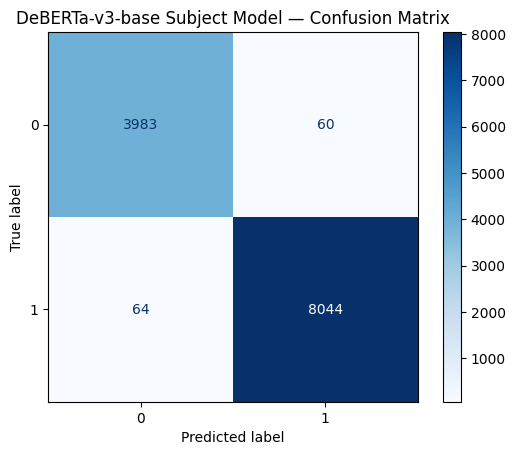

In [ ]:
print("===== VALIDATION METRICS =====")
metrics = trainer.evaluate()

for key, value in metrics.items():
    print(f"{key}: {str(value)}")

# Visualize confusion matrix
predictions = trainer.predict(val_ds)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Phishing"])
plt.figure(figsize=(6,6))
disp.plot(cmap="Blues")
plt.title("DeBERTa-v3-base Subject Model - Confusion Matrix")
plt.show()


# STEP 13 — Save Model + Tokenizer

In [ ]:
trainer.save_model("subject_encoder") 
tokenizer.save_pretrained("subject_encoder_tokenizer")

('subject_encoder_tokenizer/tokenizer_config.json',
 'subject_encoder_tokenizer/special_tokens_map.json',
 'subject_encoder_tokenizer/spm.model',
 'subject_encoder_tokenizer/added_tokens.json',
 'subject_encoder_tokenizer/tokenizer.json')

# STEP 14 — Test model with a single user input (Subject text)

In [37]:
def predict_subject(text):
    encoded = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=64,
        return_tensors="pt"
    )

    encoded = {k: v.to(model.device) for k, v in encoded.items()}
    with torch.no_grad():
        output = model(**encoded)
        pred = torch.argmax(output.logits, dim=1).item()
    
    return "🔴 PHISHING" if pred == 1 else "🟢 LEGITIMATE"


# Try any example:
while True:
    """Please confirm your banking details to avoid suspension."""
    text = input("Enter an email subject: ")
    if text.lower() == "b" or text.lower() == "break":
        break 
    print(predict_subject(text))

🔴 PHISHING
🟢 LEGITIMATE
🟢 LEGITIMATE
🟢 LEGITIMATE
🟢 LEGITIMATE
🔴 PHISHING
🟢 LEGITIMATE
🟢 LEGITIMATE
🟢 LEGITIMATE
🔴 PHISHING
🔴 PHISHING
🔴 PHISHING
🔴 PHISHING
🟢 LEGITIMATE
🟢 LEGITIMATE
🟢 LEGITIMATE
🔴 PHISHING
